In [ ]:
import pynini
import numpy as np
from typing import NamedTuple
from dataclasses import dataclass

In [34]:
ascii_table = pynini.SymbolTable()
ascii_table.add_symbol("<eps>")

for i in range(1, 1_000):
    ascii_table.add_symbol(chr(i))

In [35]:
lexicon = [
    "foo",
    "fee",
    "ffoo",
    "bar",
    "boar",
    "fbar",
]

In [61]:
min_word_len = 3
max_word_len = 10
num_words = 10_000

alpha_start = ord('a')
alpha_end = ord('z')

def generate_random_word():
    word_len = np.random.randint(low=min_word_len, high=max_word_len, size=(1,)).item()
    random_ints = np.random.randint(low=alpha_start, high=alpha_end, size=(word_len,))
    random_word = ''.join(chr(i) for i in random_ints)
    return random_word

random_wordlist = [generate_random_word() for _ in range(num_words)]

random_wordlist[:10]

['bljkvcrti',
 'cffqm',
 'mghdcxvbp',
 'dfwyw',
 'kudwm',
 'gsr',
 'sskbfglgu',
 'khxeqd',
 'uodbwckum',
 'gblexwexf']

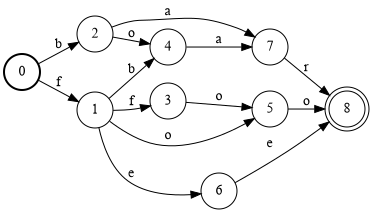

In [62]:
L = pynini.union(*lexicon)
L.set_input_symbols(ascii_table)
L.optimize()
L

In [63]:
Lrand = pynini.union(*random_wordlist)
Lrand.set_input_symbols(ascii_table)
Lrand.optimize()
Lrand.num_states()

14484

In [38]:
class WfsaCsr(NamedTuple):
    """
    Compressed Sparse Row representation of a WFSA with m states and n arcs.
    - `offsets`: n+1 array mapping state index to the first arc index
    - `final`: n array indicating final states
    - `next_states`: m array mapping arc index to target state index
    - `weights`: m array containing arc weights
    - `labels`: m array containing input labels for arcs
    """

    offsets: np.ndarray
    next_states: np.ndarray
    weights: np.ndarray
    final: np.ndarray
    labels: np.ndarray

    @classmethod
    def from_pynini(cls, wfsa: pynini.Fst) -> "WfsaCsr":
        """
        Compute a Compressed Sparse Row representation for the given FST.

        Arguments:
        - `fst`: the input FST to convert
        Returns:
        A `CSR` named tuple containing the CSR representation of the FST.
        """

        # beam search will expect an epsilon-free deterministic arc-sorted WFSA
        wfsa = pynini.determinize(wfsa)
        wfsa = pynini.rmepsilon(wfsa)
        wfsa = pynini.arcsort(wfsa)

        n = wfsa.num_states()

        # store final states
        final = np.zeros(n, dtype=bool)
        zero_weight = pynini.Weight.zero(wfsa.weight_type())

        # first compute offsets by counting the number of arcs leaving each state
        # check for final weights in same loop
        offsets = np.zeros(n + 1, dtype=np.int32)
        for s in wfsa.states():
            if wfsa.final(s) != zero_weight:
                final[s] = True
            offsets[s + 1] = wfsa.num_arcs(s)

        # then compute the prefix sum to get the starting index of arcs for each state
        np.cumsum(offsets, out=offsets)

        # the total number of arcs is the last value in offsets
        # (equivalent to the 'starting arc' of the final state, which has no outgoing arcs)
        total = int(offsets[-1])

        # arc arrays
        next_states = np.empty(total, dtype=np.int32)
        weights = np.empty(total, dtype=np.float32)
        labels = np.empty(total, dtype=np.int32)

        # populate the arc arrays by iterating over states and arcs
        for s in wfsa.states():
            i = offsets[s]
            for arc in wfsa.arcs(s):
                next_states[i] = arc.nextstate
                weights[i] = float(arc.weight)  # tropical -> float
                labels[i] = arc.ilabel
                i += 1

        return cls(
            offsets=offsets,
            final=final,
            next_states=next_states,
            weights=weights,
            labels=labels,
        )


@dataclass
class WfsaCsrBeam:
    left_state: int
    right_state: int
    path_weight: float
    final: bool
    labels: list[int]

In [39]:
def decode_beam(beam: WfsaCsrBeam) -> tuple[str, float]:
    decoded_labels = [ascii_table.find(label) for label in beam.labels]
    string = "".join(decoded_labels)
    return string, beam.path_weight

In [40]:
WfsaCsr.from_pynini(L)

WfsaCsr(offsets=array([ 0,  2,  4,  8,  9, 10, 11, 12, 13, 13], dtype=int32), next_states=array([1, 2, 3, 4, 4, 5, 6, 7, 8, 3, 8, 7, 8], dtype=int32), weights=array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32), final=array([False, False, False, False, False, False, False, False,  True]), labels=array([ 98, 102,  97, 111,  98, 101, 102, 111, 114,  97, 101, 111, 111],
      dtype=int32))

In [41]:
def get_next_beams(
    beam: WfsaCsrBeam, left: WfsaCsr, right: WfsaCsr
) -> list[WfsaCsrBeam]:
    next_beams = []

    left_start_arc = left.offsets[beam.left_state]
    left_end_arc = left.offsets[beam.left_state + 1]

    right_start_arc = right.offsets[beam.right_state]
    right_end_arc = right.offsets[beam.right_state + 1]

    left_labels = left.labels[left_start_arc:left_end_arc]
    right_labels = right.labels[right_start_arc:right_end_arc]

    # since arcs are sorted, find matching labels
    # by checking for matches monotonically
    max_arcs = max(len(left_labels), len(right_labels))

    i = 0
    left_i = 0
    right_i = 0
    while (
        (i < max_arcs) and (left_i < len(left_labels)) and (right_i < len(right_labels))
    ):
        left_label = left_labels[left_i]
        right_label = right_labels[right_i]
        if left_label == right_label:
            left_next_state = left.next_states[left_start_arc + left_i]
            right_next_state = right.next_states[right_start_arc + right_i]

            left_weight = left.weights[left_start_arc + left_i]
            right_weight = right.weights[right_start_arc + right_i]

            is_final = left.final[left_next_state] and right.final[right_next_state]

            curr_beam = WfsaCsrBeam(
                left_state=left_next_state,
                right_state=right_next_state,
                path_weight=beam.path_weight + left_weight + right_weight,
                labels=beam.labels + [left_label.item()],
                final=is_final,
            )
            next_beams.append(curr_beam)

            left_i += 1
            right_i += 1

        elif left_label < right_label:
            left_i += 1
        else:
            # right_label < left_label
            right_i += 1

    return next_beams

In [42]:
def get_next_beams_fuzzy(
    beam: WfsaCsrBeam, left: WfsaCsr, right: WfsaCsr
) -> list[WfsaCsrBeam]:
    """
    Computes next beams allowing for inexact matches,
    weighted by Levenshtein edit distance
    """
    next_beams = []

    left_start_arc = left.offsets[beam.left_state]
    left_end_arc = left.offsets[beam.left_state + 1]

    right_start_arc = right.offsets[beam.right_state]
    right_end_arc = right.offsets[beam.right_state + 1]

    left_labels = left.labels[left_start_arc:left_end_arc]
    right_labels = right.labels[right_start_arc:right_end_arc]

    # consider all possible matches and substitutions
    for left_i, left_label in enumerate(left_labels):
        for right_i, right_label in enumerate(right_labels):
            edit_weight = 1 if left_label != right_label else 0

            left_next_state = left.next_states[left_start_arc + left_i]
            left_weight = left.weights[left_start_arc + left_i]

            right_next_state = right.next_states[right_start_arc + right_i]
            right_weight = right.weights[right_start_arc + right_i]

            hypothesis_weight = (
                beam.path_weight + edit_weight + left_weight + right_weight
            )
            is_final = left.final[left_next_state] and right.final[right_next_state]

            hypothesis = WfsaCsrBeam(
                left_state=left_next_state,
                right_state=right_next_state,
                path_weight=hypothesis_weight,
                final=is_final,
                labels=beam.labels + [right_label.item()],
            )
            next_beams.append(hypothesis)

    # consider deletions (of left language)
    for left_i, left_label in enumerate(left_labels):
        delete_weight = 1

        left_next_state = left.next_states[left_start_arc+left_i]
        left_weight = left.weights[left_start_arc+left_i]

        is_final = left.final[left_next_state] and right.final[beam.right_state]
        hypothesis_weight = beam.path_weight + delete_weight + left_weight

        hypothesis = WfsaCsrBeam(
            left_state=left_next_state,
            right_state=beam.right_state,
            path_weight=hypothesis_weight,
            labels=beam.labels,
            final=is_final,
        )
        next_beams.append(hypothesis)

    # consider insertions (of left language)
    for right_i, right_label in enumerate(right_labels):
        delete_weight = 1

        right_next_state = right.next_states[right_start_arc+right_i]
        right_weight = right.weights[right_start_arc+right_i]

        is_final = left.final[beam.left_state] and right.final[right_next_state]
        hypothesis_weight = beam.path_weight + delete_weight + right_weight

        hypothesis = WfsaCsrBeam(
            left_state=beam.left_state,
            right_state=right_next_state,
            path_weight=hypothesis_weight,
            labels=beam.labels + [right_label.item()],
            final=is_final,
        )
        next_beams.append(hypothesis)

    return next_beams

In [43]:
def intersect_beam(
    left: WfsaCsr, right: WfsaCsr, num_beam: int = 5, fuzzy_search: bool = False
) -> list[int]:
    """
    Compose left FstCsr with right, pruning the top `num_beams`
    paths.
    """

    # initialize w/ single beam starting at initial state

    start_state_is_final = left.final[0] and right.final[0]
    initial_beam = WfsaCsrBeam(
        left_state=0,
        right_state=0,
        path_weight=0.0,
        labels=[],
        final=start_state_is_final,
    )
    beams = [initial_beam]
    successful_beams = []

    while beams:
        next_beams = []
        for beam in beams:
            if fuzzy_search:
                beams_from_current = get_next_beams_fuzzy(beam, left, right)
            else:
                beams_from_current = get_next_beams(beam, left, right)
            beams_from_current.sort(key=lambda b: b.path_weight)
            beams_from_current = beams_from_current[:num_beam]

            for next_beam in beams_from_current:
                if next_beam.final:
                    successful_beams.append(next_beam)
                next_beams.append(next_beam)

        successful_beams.sort(key=lambda b: b.path_weight)
        successful_beams = successful_beams[:num_beam]
        beams = next_beams

    return successful_beams

In [46]:
bar = pynini.accep("bar")
bar_csr = WfsaCsr.from_pynini(bar)

L_csr = WfsaCsr.from_pynini(L)
result = intersect_beam(bar_csr, L_csr)
[decode_beam(beam) for beam in result]

[('bar', np.float32(0.0))]

In [48]:
baar = pynini.accep("bafddsar")
baar_csr = WfsaCsr.from_pynini(baar)

result = intersect_beam(baar_csr, L_csr, fuzzy_search=True)
[decode_beam(beam) for beam in result]

[('bar', np.float32(5.0)),
 ('boar', np.float32(5.0)),
 ('boar', np.float32(5.0)),
 ('boar', np.float32(5.0)),
 ('boar', np.float32(5.0))]

### TO-DO
- Only output unique paths
- Time profile beam search queries vs. edit graph composition queries.
- Time profile CSR construction vs. edit graph construction (low priority)

In [64]:
Lrand_csr = WfsaCsr.from_pynini(Lrand)

result = intersect_beam(baar_csr, Lrand_csr, fuzzy_search=True)
[decode_beam(beam) for beam in result]

[('bafcwh', np.float32(5.0)),
 ('bafcwh', np.float32(5.0)),
 ('bafcwh', np.float32(5.0)),
 ('bafcwh', np.float32(5.0)),
 ('bafcwh', np.float32(5.0))]